# GCP Marker Detection Pipeline
**Tasks:** Keypoint Localization (x,y) + Shape Classification (Cross / Square / L-Shape)

**Architecture:** EfficientNet-B3 backbone with dual head (regression + classification)

## 1. Setup & Installs

In [1]:
!pip install -q timm albumentations==1.4.3 scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 6.2 MB/s eta 0:00:00


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

os.makedirs('/content/data', exist_ok=True)

# Unzip train
if not os.path.exists('/content/data/train_dataset'):
    print('Unzipping train_dataset...')
    !unzip -q "/content/drive/MyDrive/train_dataset-20260613T170018Z-3-001.zip" -d /content/data/
    print('Train done!')

# Unzip test
if not os.path.exists('/content/data/test_dataset'):
    print('Unzipping test_dataset...')
    !unzip -q "/content/drive/MyDrive/test_dataset-20260613T170021Z-3-001.zip" -d /content/data/
    print('Test done!')

# Verify
total = sum(1 for r,d,f in os.walk('/content/data') for x in f if x.upper().endswith('.JPG'))
print(f'Total images found: {total}')
print('Contents:', os.listdir('/content/data'))

Unzipping train_dataset...
Train done!
Unzipping test_dataset...
Test done!
Total images found: 927
Contents: ['train_dataset', 'test_dataset']


In [5]:
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [6]:
# ===== PATHS & CONFIG =====
TRAIN_DIR = '/content/data/train_dataset'
TEST_DIR  = '/content/data/test_dataset'
JSON_PATH = '/content/data/train_dataset/gcp_marks.json'
SAVE_DIR  = '/content/drive/MyDrive/gcp_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE      = 256
CROP_SIZE     = 384
BATCH_SIZE    = 8
EPOCHS        = 50
LR            = 3e-4
BACKBONE      = 'efficientnet_b0'
SHAPE_CLASSES = ['Cross', 'L-Shape', 'Square']
NUM_CLASSES   = 3
CLASS_TO_IDX  = {c: i for i, c in enumerate(SHAPE_CLASSES)}
IDX_TO_CLASS  = {i: c for c, i in CLASS_TO_IDX.items()}
print('Config ready.')

Config ready.


In [7]:
import os

# Find the JSON
for root, dirs, files in os.walk('/content/data'):
    for f in files:
        if f.endswith('.json'):
            print(os.path.join(root, f))

# Also check train_dataset contents
print('\nTrain dataset folders:')
for item in os.listdir('/content/data/train_dataset'):
    print(' ', item)

/content/data/train_dataset/gcp_marks.json

Train dataset folders:
  Egypt-New city
  231129_CTD
  Vedanta GOA Bicholim
  scout_973
  Seashell Ras el Hekma
  Adani GP-III CG
  UTCL UNCL Additional Area
  RDCW-Reddipalayam Limestone Mine
  scout_971
  gcp_marks.json
  Deora Limestone Mine
  scout_966


## 2. EDA

In [8]:
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ===== PATHS & CONFIG =====
TRAIN_DIR = '/content/data/train_dataset'
TEST_DIR  = '/content/data/test_dataset'
JSON_PATH = '/content/data/train_dataset/gcp_marks.json'
SAVE_DIR  = '/content/drive/MyDrive/gcp_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = 256
CROP_SIZE  = 384
BATCH_SIZE = 8
BACKBONE   = 'efficientnet_b0'
EPOCHS        = 50
LR            = 3e-4
SHAPE_CLASSES = ['Cross', 'L-Shape', 'Square']
NUM_CLASSES   = 3
CLASS_TO_IDX  = {c: i for i, c in enumerate(SHAPE_CLASSES)}
IDX_TO_CLASS  = {i: c for c, i in CLASS_TO_IDX.items()}
print('Config ready.')

Device: cuda
GPU: Tesla T4
Config ready.


In [9]:
with open(JSON_PATH) as f:
    annotations = json.load(f)

records = []
for path, ann in annotations.items():
    parts = path.split('/')
    records.append({
        'rel_path': path,
        'x': ann['mark']['x'],
        'y': ann['mark']['y'],
        'shape': ann.get('verified_shape', None),
        'project': parts[0],
        'gcp_id': parts[2]
    })

df = pd.DataFrame(records)
print(f'Total: {len(df)}, Missing shape: {df["shape"].isna().sum()}')
print(df['shape'].value_counts())

Total: 1000, Missing shape: 4
shape
L-Shape    491
Square     328
Cross      177
Name: count, dtype: int64


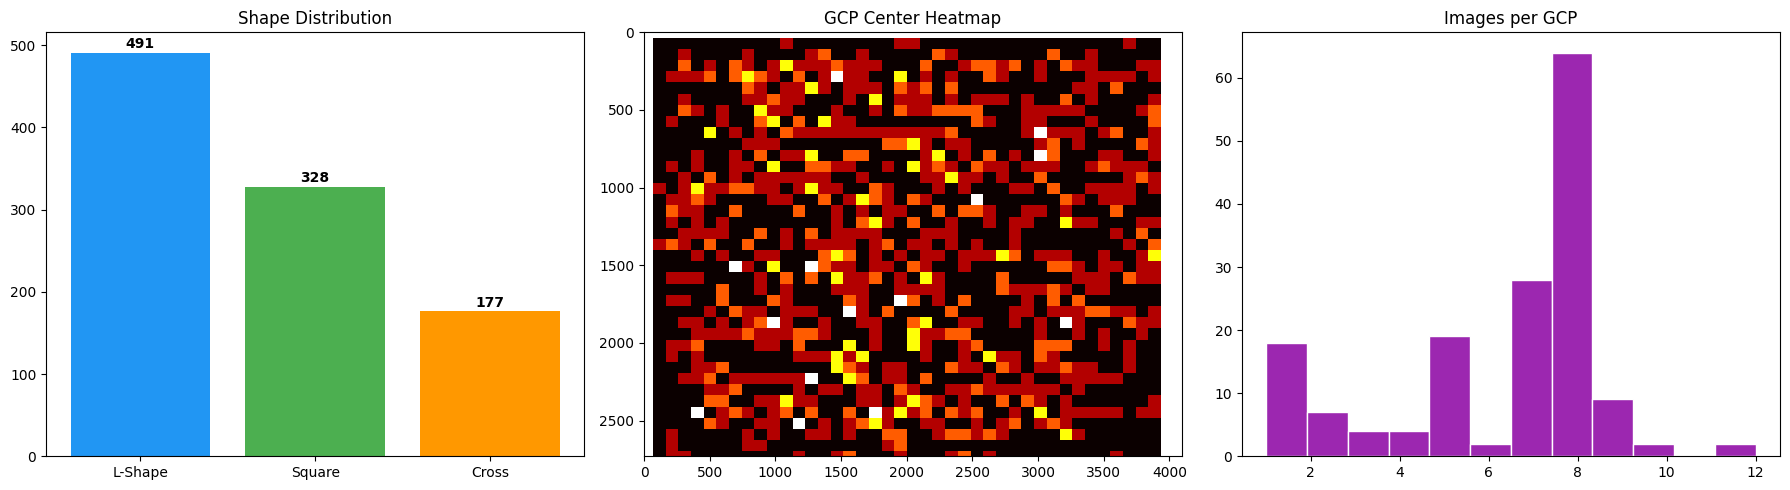

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc = df['shape'].value_counts()
axes[0].bar(sc.index, sc.values, color=['#2196F3','#4CAF50','#FF9800'])
axes[0].set_title('Shape Distribution')
for i, v in enumerate(sc.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

axes[1].hist2d(df['x'], df['y'], bins=40, cmap='hot')
axes[1].set_title('GCP Center Heatmap')
axes[1].set_xlim(0, 4096); axes[1].set_ylim(2730, 0)

gpg = df.groupby(['project','gcp_id']).size()
axes[2].hist(gpg.values, bins=12, color='#9C27B0', edgecolor='white')
axes[2].set_title('Images per GCP')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eda.png', dpi=150)
plt.show()

## 3. Dataset & DataLoader

In [11]:
from sklearn.model_selection import GroupShuffleSplit

clean_df = df.dropna(subset=['shape']).reset_index(drop=True)
clean_df['gcp_key'] = clean_df['project'] + '/' + clean_df['gcp_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss.split(clean_df, groups=clean_df['gcp_key']))
train_df = clean_df.iloc[train_idx].reset_index(drop=True)
val_df   = clean_df.iloc[val_idx].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)}')
print(f'Train shapes: {train_df["shape"].value_counts().to_dict()}')
print(f'Val shapes:   {val_df["shape"].value_counts().to_dict()}')

Train: 853 | Val: 143
Train shapes: {'L-Shape': 448, 'Square': 256, 'Cross': 149}
Val shapes:   {'Square': 72, 'L-Shape': 43, 'Cross': 28}


In [12]:
def get_transforms(mode='train', img_size=IMG_SIZE):
    kp = A.KeypointParams(format='xy', remove_invisible=False)
    if mode == 'train':
        return A.Compose([
            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.OneOf([
                A.GaussNoise(var_limit=(10,50), p=1),
                A.GaussianBlur(blur_limit=3, p=1)
            ], p=0.4),
            A.OneOf([
                A.RandomBrightnessContrast(0.3, 0.3, p=1),
                A.HueSaturationValue(p=1),
                A.CLAHE(p=1)
            ], p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15,
                               border_mode=cv2.BORDER_REFLECT, p=0.5),
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], keypoint_params=kp)
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], keypoint_params=kp)


class GCPDataset(Dataset):
    def __init__(self, df, img_root, crop_size=CROP_SIZE, img_size=IMG_SIZE, mode='train'):
        self.df = df; self.img_root = img_root
        self.crop_size = crop_size; self.img_size = img_size
        self.mode = mode; self.transform = get_transforms(mode, img_size)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_root, row['rel_path'])
        img = cv2.imread(img_path)

        # Handle corrupt/missing images
        if img is None:
            # Return a black image with center keypoint as fallback
            img = np.zeros((self.crop_size, self.crop_size, 3), dtype=np.uint8)
            t = self.transform(image=img, keypoints=[(self.crop_size//2, self.crop_size//2)])
            return (t['image'],
                    torch.tensor([0.5, 0.5], dtype=torch.float32),
                    torch.tensor(0, dtype=torch.long),
                    {'x1': 0, 'y1': 0, 'rel_path': row['rel_path']})

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = img.shape[:2]
        cx, cy = row['x'], row['y']
        half = self.crop_size // 2

        if self.mode == 'train':
            jitter = self.crop_size // 6
            cx_j = cx + random.randint(-jitter, jitter)
            cy_j = cy + random.randint(-jitter, jitter)
        else:
            cx_j, cy_j = cx, cy

        x1 = int(np.clip(cx_j - half, 0, orig_w - self.crop_size))
        y1 = int(np.clip(cy_j - half, 0, orig_h - self.crop_size))
        crop = img[y1:y1+self.crop_size, x1:x1+self.crop_size]
        kp_x = cx - x1; kp_y = cy - y1

        t = self.transform(image=crop, keypoints=[(kp_x, kp_y)])
        image = t['image']; kps = t['keypoints']
        kx, ky = (kps[0][0]/self.img_size, kps[0][1]/self.img_size) if len(kps) > 0 else (0.5, 0.5)

        return (image,
                torch.tensor([kx, ky], dtype=torch.float32),
                torch.tensor(CLASS_TO_IDX[row['shape']], dtype=torch.long),
                {'x1': x1, 'y1': y1, 'rel_path': row['rel_path']})

print('Dataset class defined.')

Dataset class defined.


In [13]:
sc_train = train_df['shape'].value_counts(); total = len(train_df)
class_weights = torch.tensor(
    [total / (NUM_CLASSES * sc_train.get(c, 1)) for c in SHAPE_CLASSES],
    dtype=torch.float32).to(DEVICE)
print(f'Class weights: {dict(zip(SHAPE_CLASSES, class_weights.cpu().numpy().round(3)))}')

train_ds     = GCPDataset(train_df, TRAIN_DIR, mode='train')
val_ds       = GCPDataset(val_df,   TRAIN_DIR, mode='val')
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)}')

Class weights: {'Cross': np.float32(1.908), 'L-Shape': np.float32(0.635), 'Square': np.float32(1.111)}
Train batches: 107 | Val: 18


/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/transforms.py:190: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(


## 4. Model

In [14]:
class GCPNet(nn.Module):
    def __init__(self, backbone=BACKBONE, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=pretrained,
                                          num_classes=0, global_pool='avg')
        fd = self.backbone.num_features
        self.dropout  = nn.Dropout(0.3)
        self.reg_head = nn.Sequential(nn.Linear(fd,256), nn.ReLU(), nn.Dropout(0.2),
                                      nn.Linear(256,2), nn.Sigmoid())
        self.cls_head = nn.Sequential(nn.Linear(fd,256), nn.ReLU(), nn.Dropout(0.2),
                                      nn.Linear(256,num_classes))

    def forward(self, x):
        f = self.dropout(self.backbone(x))
        return self.reg_head(f), self.cls_head(f)

model = GCPNet().to(DEVICE)
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
kp, cls = model(dummy)
print(f'kp:{kp.shape}, cls:{cls.shape}')
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


kp:torch.Size([2, 2]), cls:torch.Size([2, 3])
Total params: 4,664,705


## 5. Training

In [15]:
class WingLoss(nn.Module):
    def __init__(self, w=10.0, eps=2.0):
        super().__init__()
        self.w = w; self.eps = eps; self.C = w - w * np.log(1 + w/eps)
    def forward(self, pred, target):
        d = torch.abs(pred - target)
        return torch.where(d < self.w, self.w*torch.log(1+d/self.eps), d-self.C).mean()

reg_crit   = WingLoss()
cls_crit   = nn.CrossEntropyLoss(weight=class_weights)
LAMBDA_REG = 1.0; LAMBDA_CLS = 0.5
optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
print('Optimizer ready.')

Optimizer ready.


In [16]:
def pck(pred, target, thr, cs=CROP_SIZE):
    dist = torch.sqrt(((pred*cs - target*cs)**2).sum(dim=1))
    return (dist < thr).float().mean().item()

def train_epoch(model, loader, opt):
    model.train(); tl = 0
    for imgs, kp_t, cls_t, _ in loader:
        imgs, kp_t, cls_t = imgs.to(DEVICE), kp_t.to(DEVICE), cls_t.to(DEVICE)
        opt.zero_grad()
        kp_p, cls_p = model(imgs)
        loss = LAMBDA_REG*reg_crit(kp_p,kp_t) + LAMBDA_CLS*cls_crit(cls_p,cls_t)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        tl += loss.item()
    return tl / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); tl=p10=p25=p50=0; preds=[]; labels=[]
    for imgs, kp_t, cls_t, _ in loader:
        imgs, kp_t, cls_t = imgs.to(DEVICE), kp_t.to(DEVICE), cls_t.to(DEVICE)
        kp_p, cls_p = model(imgs)
        tl += LAMBDA_REG*reg_crit(kp_p,kp_t).item() + LAMBDA_CLS*cls_crit(cls_p,cls_t).item()
        p10+=pck(kp_p,kp_t,10); p25+=pck(kp_p,kp_t,25); p50+=pck(kp_p,kp_t,50)
        preds.extend(cls_p.argmax(1).cpu().tolist())
        labels.extend(cls_t.cpu().tolist())
    n = len(loader)
    acc = sum(p==l for p,l in zip(preds,labels))/len(labels)
    return {'loss':tl/n, 'pck10':p10/n, 'pck25':p25/n, 'pck50':p50/n, 'cls_acc':acc}

print('Functions ready.')

Functions ready.


In [17]:
# Check first few paths in train_df vs actual files
for i, row in train_df.head(5).iterrows():
    full_path = os.path.join(TRAIN_DIR, row['rel_path'])
    exists = os.path.exists(full_path)
    print(f'{"OK" if exists else "MISSING"}: {full_path}')

OK: /content/data/train_dataset/scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG
OK: /content/data/train_dataset/RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_dataset/LYGCP27/9_DJI_0436.JPG
OK: /content/data/train_dataset/RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_dataset/LYGCP27/9_DJI_0437.JPG
OK: /content/data/train_dataset/RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_dataset/LYGCP27/9_DJI_0438.JPG
OK: /content/data/train_dataset/RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_dataset/LYGCP27/9_DJI_0439.JPG


In [18]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

best_pck25 = 0.0; history = []
print(f'Training {EPOCHS} epochs...\n')
# ... rest of the cell stays the same
best_pck25 = 0.0; history = []
print(f'Training {EPOCHS} epochs...\n')
print(f'{"Ep":>4} | {"TrLoss":>8} | {"VaLoss":>8} | {"P@10":>6} | {"P@25":>6} | {"P@50":>6} | {"Acc":>6}')
print('-'*58)

for epoch in range(1, EPOCHS+1):
    tl = train_epoch(model, train_loader, optimizer)
    vm = evaluate(model, val_loader)
    scheduler.step()
    history.append({'epoch': epoch, 'train_loss': tl, **vm})
    print(f'{epoch:>4} | {tl:>8.4f} | {vm["loss"]:>8.4f} | {vm["pck10"]:>6.3f} | {vm["pck25"]:>6.3f} | {vm["pck50"]:>6.3f} | {vm["cls_acc"]:>6.3f}')
    if vm['pck25'] > best_pck25:
        best_pck25 = vm['pck25']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_metrics': vm,
            'config': {'backbone': BACKBONE, 'img_size': IMG_SIZE,
                       'crop_size': CROP_SIZE, 'classes': SHAPE_CLASSES}
        }, f'{SAVE_DIR}/best_model.pth')
        print(f'  *** Best saved (PCK@25={best_pck25:.3f}) ***')

print('Training complete!')

Training 50 epochs...

Training 50 epochs...

  Ep |   TrLoss |   VaLoss |   P@10 |   P@25 |   P@50 |    Acc
----------------------------------------------------------
   1 |   0.5443 |   0.3444 |  0.491 |  0.757 |  0.979 |  0.818
  *** Best saved (PCK@25=0.757) ***
   2 |   0.3813 |   0.3279 |  0.453 |  0.731 |  1.000 |  0.874
   3 |   0.3708 |   0.3490 |  0.441 |  0.806 |  0.972 |  0.860
  *** Best saved (PCK@25=0.806) ***
   4 |   0.3423 |   0.3549 |  0.629 |  0.951 |  0.993 |  0.832
  *** Best saved (PCK@25=0.951) ***
   5 |   0.3179 |   0.4602 |  0.593 |  0.931 |  0.993 |  0.818
   6 |   0.2955 |   0.3410 |  0.860 |  0.965 |  0.993 |  0.874
  *** Best saved (PCK@25=0.965) ***
   7 |   0.3074 |   0.2814 |  0.659 |  0.924 |  0.993 |  0.818
   8 |   0.2784 |   0.2886 |  0.517 |  0.694 |  0.993 |  0.888
   9 |   0.2622 |   0.2066 |  0.427 |  0.972 |  1.000 |  0.951
  *** Best saved (PCK@25=0.972) ***
  10 |   0.2284 |   0.3422 |  0.349 |  0.688 |  0.972 |  0.916
  11 |   0.1816 |   0.

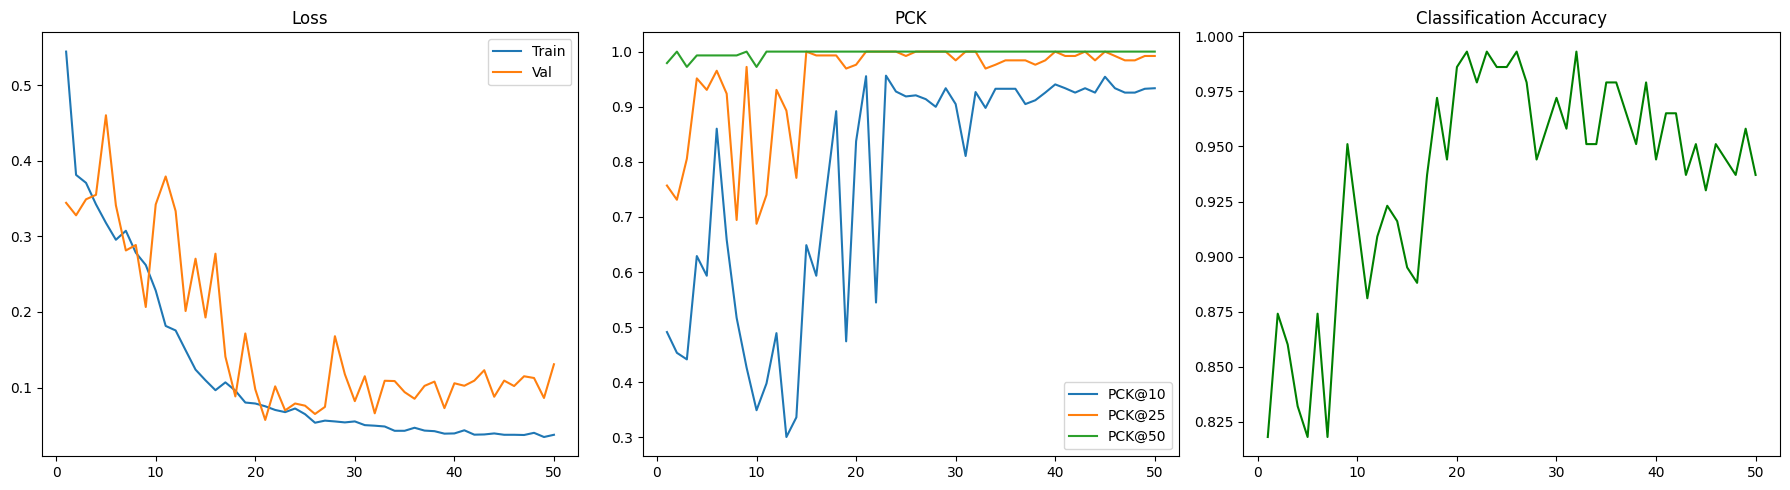

In [19]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(hist_df.epoch, hist_df.train_loss, label='Train')
axes[0].plot(hist_df.epoch, hist_df.loss, label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(hist_df.epoch, hist_df.pck10, label='PCK@10')
axes[1].plot(hist_df.epoch, hist_df.pck25, label='PCK@25')
axes[1].plot(hist_df.epoch, hist_df.pck50, label='PCK@50')
axes[1].set_title('PCK'); axes[1].legend()
axes[2].plot(hist_df.epoch, hist_df.cls_acc, color='green')
axes[2].set_title('Classification Accuracy')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/curves.png', dpi=150)
plt.show()

## 6. Inference on Test Set

In [20]:
ckpt = torch.load(f'{SAVE_DIR}/best_model.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded epoch {ckpt['epoch']}, metrics: {ckpt['val_metrics']}")
val_tfm = get_transforms('val', IMG_SIZE)

Loaded epoch 15, metrics: {'loss': 0.19276005665091767, 'pck10': 0.6488095257017348, 'pck25': 1.0, 'pck50': 1.0, 'cls_acc': 0.8951048951048951}


In [21]:
@torch.no_grad()
def predict_image(img_path, model, crop_size=CROP_SIZE, batch_size=8):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]; cs = crop_size; stride = cs // 2
    crops = []; offsets = []
    ys = list(range(0, h-cs, stride)) + [h-cs]
    xs = list(range(0, w-cs, stride)) + [w-cs]
    for y1 in ys:
        for x1 in xs:
            y1c = max(0, min(y1, h-cs)); x1c = max(0, min(x1, w-cs))
            crop = img[y1c:y1c+cs, x1c:x1c+cs]
            crops.append(val_tfm(image=crop, keypoints=[])['image'])
            offsets.append((x1c, y1c))
    best_conf = -1; best = None
    for i in range(0, len(crops), batch_size):
        b = torch.stack(crops[i:i+batch_size]).to(DEVICE)
        kp_p, cls_p = model(b)
        probs = torch.softmax(cls_p, dim=1); confs, preds = probs.max(dim=1)
        for j in range(len(b)):
            conf = confs[j].item()
            if conf > best_conf:
                best_conf = conf; ox, oy = offsets[i+j]
                best = {'x': float(kp_p[j,0].item()*cs+ox),
                        'y': float(kp_p[j,1].item()*cs+oy),
                        'shape': IDX_TO_CLASS[preds[j].item()]}
    return best

print('Inference function ready.')

Inference function ready.


In [22]:
test_root = Path(TEST_DIR)
test_imgs = sorted(test_root.rglob('*.JPG')) + sorted(test_root.rglob('*.jpg'))
test_rels = [str(p.relative_to(test_root)) for p in test_imgs]
print(f'Found {len(test_imgs)} test images')

Found 300 test images


In [23]:
from tqdm.notebook import tqdm

predictions = {}; errors = []
for img_path, rel_path in tqdm(zip(test_imgs, test_rels), total=len(test_imgs)):
    try:
        r = predict_image(img_path, model)
        predictions[rel_path] = {
            'mark': {'x': r['x'], 'y': r['y']},
            'verified_shape': r['shape']
        }
    except Exception as e:
        errors.append((rel_path, str(e)))
        print(f'Error: {rel_path}: {e}')

print(f'Done! Predictions: {len(predictions)}, Errors: {len(errors)}')

Done! Predictions: 300, Errors: 0


In [24]:
out = f'{SAVE_DIR}/predictions.json'
with open(out, 'w') as f:
    json.dump(predictions, f, indent=2)

print(f'Saved: {out}')
print('Sample predictions:')
for k, v in list(predictions.items())[:3]:
    print(f'  {k}: x={v["mark"]["x"]:.1f}, y={v["mark"]["y"]:.1f}, shape={v["verified_shape"]}')

Saved: /content/drive/MyDrive/gcp_outputs/predictions.json
Sample predictions:
  231129_CTD/231129_CTD_GDA94/11/DJI_20231129142314_0151.JPG: x=2495.4, y=986.2, shape=Cross
  231129_CTD/231129_CTD_GDA94/2/DJI_20231129130143_0430.JPG: x=2321.4, y=2540.8, shape=Cross
  231129_CTD/231129_CTD_GDA94/2/DJI_20231129130145_0431.JPG: x=600.6, y=1138.8, shape=Cross
